# Module 2 - Analytics Pipeline

## Exploratory Data Analysis (EDA)

**Project:** Zepto Data & AI Platform

**Author:** Joniboyina Jeevan Venkatesh

This notebook performs:

- Dataset loading
- Dataset profiling
- Missing value analysis
- Data cleaning
- Exploratory Data Analysis
- Data visualization

In [18]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

In [19]:
#Load Dataset
df = sns.load_dataset("titanic")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [20]:
#Save Offline Copy
df.to_csv("titanic.csv", index=False)

print("Offline copy saved successfully.")

Offline copy saved successfully.


In [21]:
#Profile Dataset
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None


In [22]:
print(df.describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [23]:
print(df.shape)

(891, 15)


In [24]:
# Missing Value Percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage[missing_percentage > 0]

missing_percentage = missing_percentage.sort_values(ascending=False)

print(missing_percentage)

deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


In [25]:
#Convert to DataFrame
missing_df = pd.DataFrame({
    "Missing Percentage": missing_percentage
})

missing_df

,Missing Percentage
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467


## Missing Value Handling Strategy

Based on the assignment requirements:

- Missing values below **5%** → Drop the affected rows.
- Missing values between **5% and 30%** → Impute the values.
- Missing values above **30%** → Drop the column or encode "Missing" as a category with justification.

In [33]:
# Copy dataset

clean_df = df.copy()

In [34]:
# Cabin has very high missing percentage

clean_df.drop(columns=["deck"], inplace=True)

In [35]:
#Handle age
# Fill missing age values with median
clean_df["age"] = clean_df["age"].fillna(clean_df["age"].median())

In [36]:
#Handle embarked
# Fill missing embarked values with mode
clean_df["embarked"] = clean_df["embarked"].fillna(
    clean_df["embarked"].mode()[0]
)

In [37]:
#Handle embark_town
# Fill missing embark_town values with mode
clean_df["embark_town"] = clean_df["embark_town"].fillna(
    clean_df["embark_town"].mode()[0]
)

In [38]:
#Verify Missing Values
clean_df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

## Missing Value Handling

The missing values were handled according to the assignment rules.

- **Age (19.87% missing):** Imputed using the median because the missing percentage lies between 5% and 30%.
- **Embarked (0.22% missing):** The affected rows were filled with the mode since only two values were missing.
- **Embark Town (0.22% missing):** Filled with the mode for the same reason.
- **Deck (77.22% missing):** Dropped because the missing percentage was too high, making reliable imputation impractical.

# Univariate Analysis

This section analyzes the distribution of the numerical features **Age** and **Fare** using histograms and box plots. Outliers are identified using the Interquartile Range (IQR) method, and the distribution of Fare is interpreted using the mean, median, and mode.

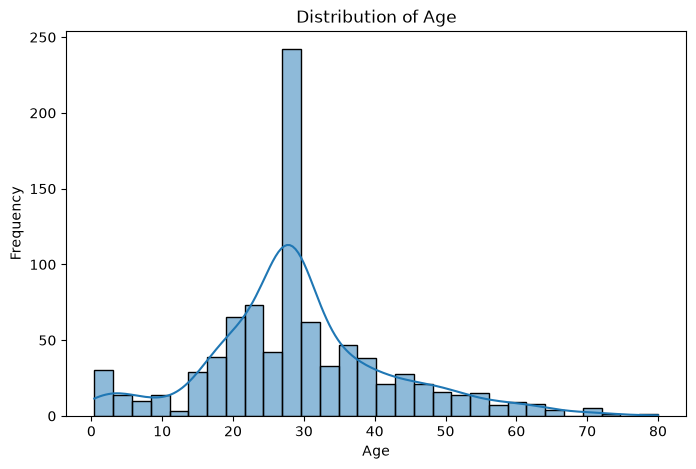

In [39]:
#Histogram of Age
plt.figure(figsize=(8,5))

sns.histplot(clean_df["age"], bins=30, kde=True)

plt.title("Distribution of Age")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

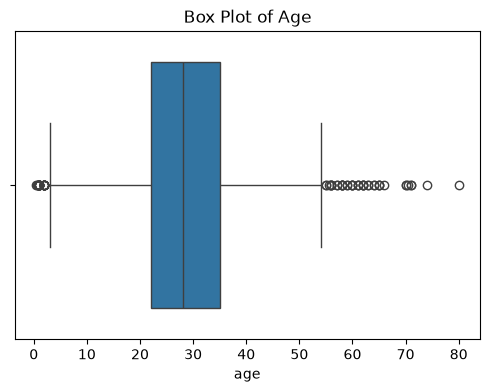

In [40]:
#Box Plot of Age
plt.figure(figsize=(6,4))

sns.boxplot(x=clean_df["age"])

plt.title("Box Plot of Age")

plt.show()

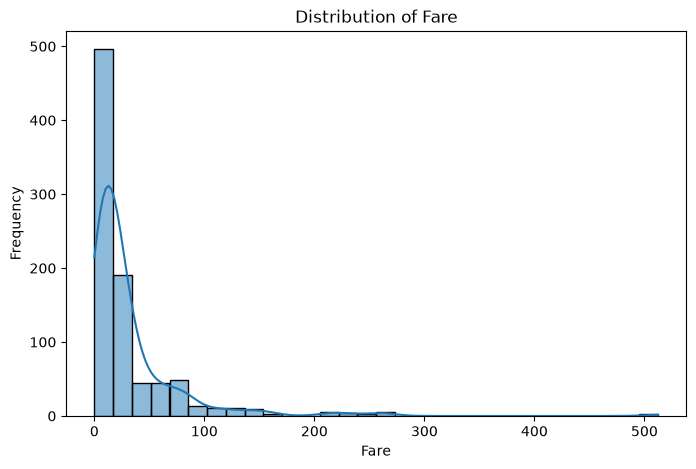

In [41]:
#Histogram of fare
plt.figure(figsize=(8,5))

sns.histplot(clean_df["fare"], bins=30, kde=True)

plt.title("Distribution of Fare")

plt.xlabel("Fare")

plt.ylabel("Frequency")

plt.show()

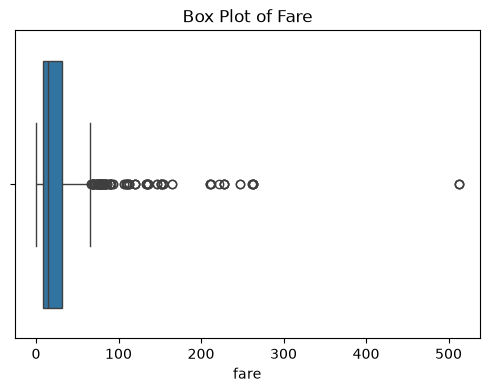

In [42]:
#Box Plot of Fare
plt.figure(figsize=(6,4))

sns.boxplot(x=clean_df["fare"])

plt.title("Box Plot of Fare")

plt.show()

In [43]:
#Age Outliers
Q1 = clean_df["age"].quantile(0.25)
Q3 = clean_df["age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

age_outliers = clean_df[
    (clean_df["age"] < lower) |
    (clean_df["age"] > upper)
]

print("Age Outliers:", len(age_outliers))

Age Outliers: 66


In [44]:
#Fare Outliers
Q1 = clean_df["fare"].quantile(0.25)
Q3 = clean_df["fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

fare_outliers = clean_df[
    (clean_df["fare"] < lower) |
    (clean_df["fare"] > upper)
]

print("Fare Outliers:", len(fare_outliers))

Fare Outliers: 116


In [45]:
#Statistical Data
print("Mean :", clean_df["fare"].mean())

print("Median :", clean_df["fare"].median())

print("Mode :")

print(clean_df["fare"].mode())

Mean : 32.204207968574636
Median : 14.4542
Mode :
0    8.05
Name: fare, dtype: float64


## Interpretation

### Age

The histogram shows the distribution of passenger ages, while the box plot highlights the presence of outliers identified using the IQR method.

### Fare

The histogram and box plot indicate that the Fare distribution contains several high-value outliers. The distribution is expected to be **right-skewed** because the mean is greater than the median, and the median is greater than or close to the mode. This indicates that a small number of passengers paid significantly higher fares than the majority.

# Bivariate Analysis

This section explores the relationship between passenger characteristics and survival. The analysis includes survival rates by gender, passenger class, and the combination of both. It also examines correlations among the specified numeric variables.

In [46]:
# Survival Rate by Sex

survival_by_sex = clean_df.groupby("sex")["survived"].mean() * 100

print("Survival Rate by Sex")

print(survival_by_sex)

Survival Rate by Sex
sex
female    74.203822
male      18.890815
Name: survived, dtype: float64


In [47]:
# Survival Rate by Passenger Class

survival_by_class = clean_df.groupby("pclass")["survived"].mean() * 100

print("Survival Rate by Passenger Class")

print(survival_by_class)

Survival Rate by Passenger Class
pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64


In [48]:
# Survival Rate by Sex and Passenger Class

survival_by_both = (
    clean_df
    .groupby(["sex", "pclass"])["survived"]
    .mean()
    * 100
)

print("Survival Rate by Sex and Passenger Class")

print(survival_by_both)

Survival Rate by Sex and Passenger Class
sex     pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: survived, dtype: float64


In [49]:
#Correlation Matrix
corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = clean_df[corr_columns].corr()

correlation_matrix

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
sibsp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


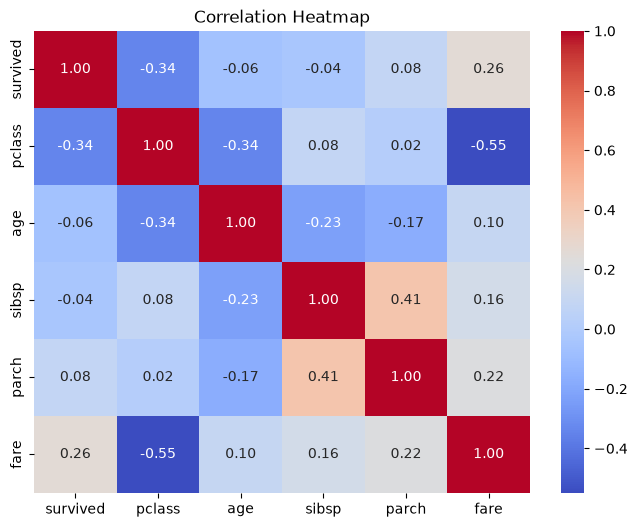

In [50]:
#Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Interpretation

- Female passengers had a much higher survival rate (74.20%) than male passengers (18.89%), indicating that gender strongly influenced survival.

- First-class passengers achieved the highest survival rate (62.96%), while third-class passengers had the lowest (24.24%), showing that passenger class had a significant impact on survival.

- The strongest negative correlation is between **Passenger Class (pclass)** and **Fare (-0.55)**, indicating that passengers in higher classes generally paid higher fares.

- The strongest positive correlation is between **Siblings/Spouses (sibsp)** and **Parents/Children (parch) (0.41)**, suggesting that passengers travelling with spouses often travelled with other family members as well.

# Multivariate Data Story

This section presents visualizations that explain the factors affecting passenger survival on the Titanic.

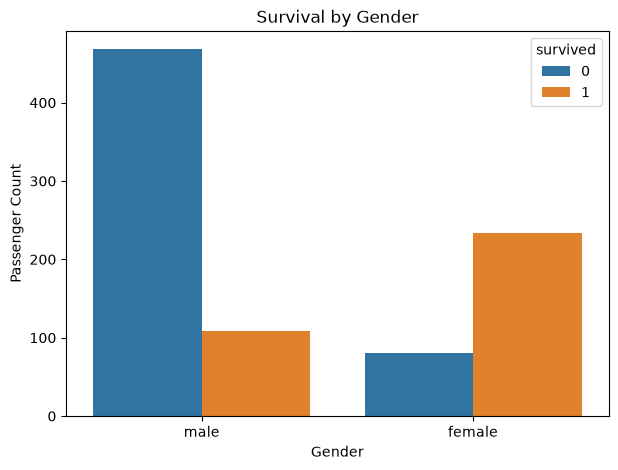

In [51]:
#Chart1--Survival by Gender
plt.figure(figsize=(7,5))

sns.countplot(
    data=clean_df,
    x="sex",
    hue="survived"
)

plt.title("Survival by Gender")

plt.xlabel("Gender")

plt.ylabel("Passenger Count")

plt.show()

### Interpretation

Female passengers had a considerably higher survival rate than male passengers. This supports the earlier statistical analysis and reflects the evacuation priority given to women during the disaster.

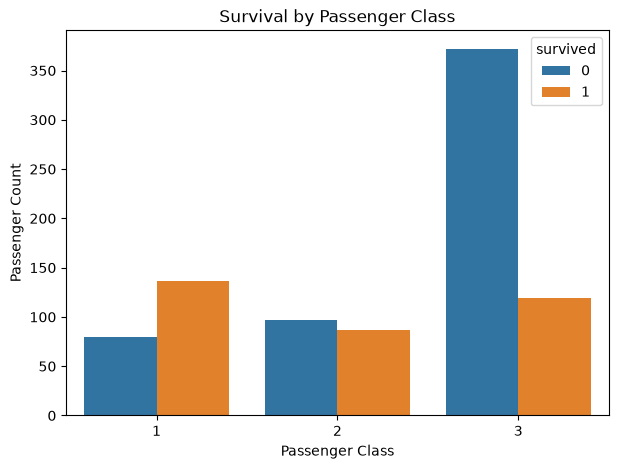

In [52]:
#Chart2--Survival by Passenger
plt.figure(figsize=(7,5))

sns.countplot(
    data=clean_df,
    x="pclass",
    hue="survived"
)

plt.title("Survival by Passenger Class")

plt.xlabel("Passenger Class")

plt.ylabel("Passenger Count")

plt.show()

### Interpretation

Passengers travelling in first class experienced the highest survival rate, while third-class passengers experienced the lowest. This suggests that socioeconomic status influenced access to lifeboats and evacuation opportunities.

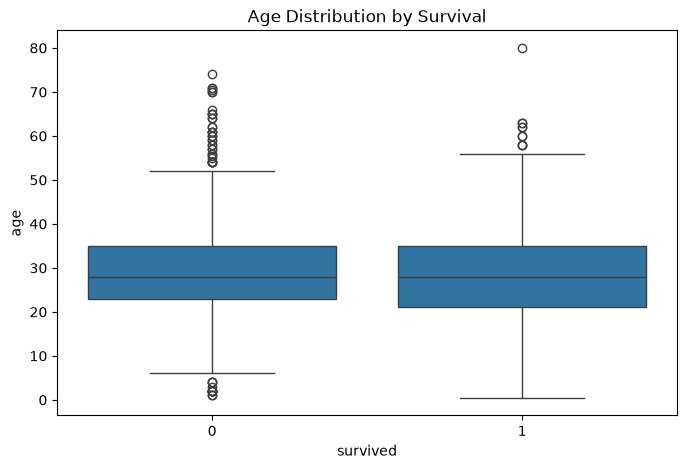

In [53]:
#Chart 3 — Age Distribution by Survival
plt.figure(figsize=(8,5))

sns.boxplot(
    data=clean_df,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival")

plt.show()

### Interpretation

The box plot compares the age distribution of survivors and non-survivors. Although passengers of different ages survived, younger passengers generally showed a slightly higher chance of survival than older passengers.

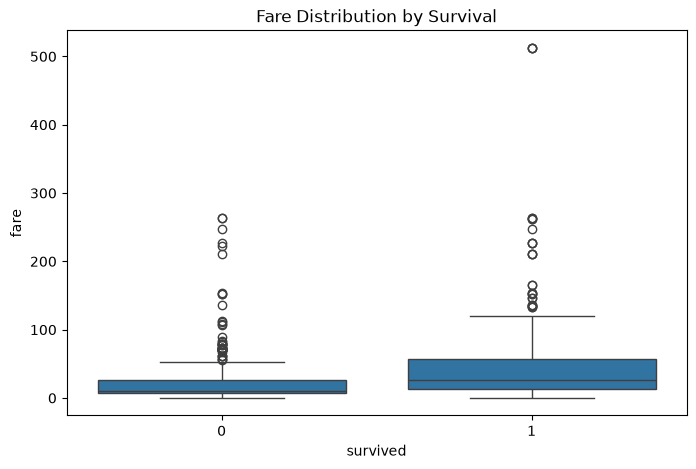

In [55]:
#Chart 4 — Fare Distribution by Survival
plt.figure(figsize=(8,5))

sns.boxplot(
    data=clean_df,
    x="survived",
    y="fare"
)

plt.title("Fare Distribution by Survival")

plt.show()

### Interpretation

Passengers who paid higher fares generally exhibited higher survival rates. Since fare is associated with passenger class, this further supports the observation that first-class passengers had better survival outcomes.

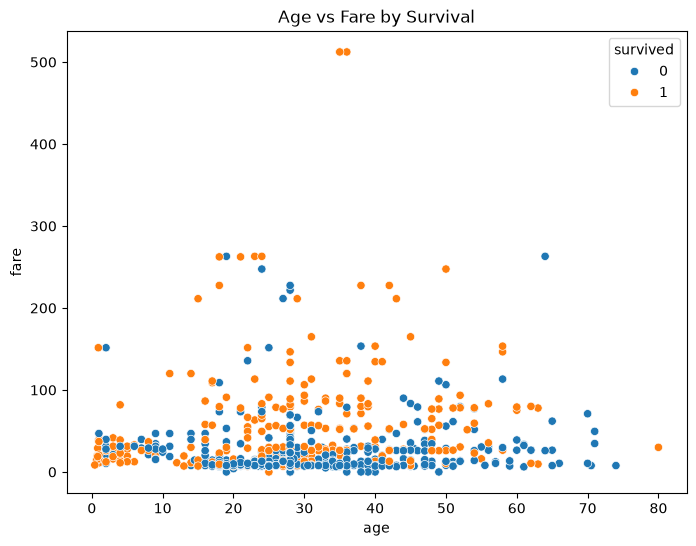

In [56]:
#Chart 5-Age vs Fare by Survival
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=clean_df,
    x="age",
    y="fare",
    hue="survived"
)

plt.title("Age vs Fare by Survival")

plt.show()

### Interpretation

The scatter plot illustrates the relationship between passenger age, ticket fare, and survival status. Survivors are more frequently observed among passengers who paid higher fares, while age alone does not clearly separate survivors from non-survivors.

# Standardization (Z-Score)

This step standardizes the **Age** and **Fare** columns using the Z-score method. It is performed only as an exploratory analysis to verify that the transformed features have approximately zero mean and unit standard deviation.

In [57]:
#Create Scaler
scaler = StandardScaler()

In [ ]:
#Standardize Age and Fare
clean_df[["age_scaled", "fare_scaled"]] = scaler.fit_transform(
    clean_df[["age", "fare"]]
)

In [ ]:
#Compare Means
print("Original Means")

print(clean_df[["age", "fare"]].mean())

print()

print("Scaled Means")

print(clean_df[["age_scaled", "fare_scaled"]].mean())

Original Means
age     29.361582
fare    32.204208
dtype: float64

Scaled Means
age_scaled     2.272780e-16
fare_scaled    3.987333e-18
dtype: float64


In [60]:
#Compare Standard Deviations
print("Original Standard Deviations")

print(clean_df[["age", "fare"]].std())

print()

print("Scaled Standard Deviations")

print(clean_df[["age_scaled", "fare_scaled"]].std())

Original Standard Deviations
age     13.019697
fare    49.693429
dtype: float64

Scaled Standard Deviations
age_scaled     1.000562
fare_scaled    1.000562
dtype: float64


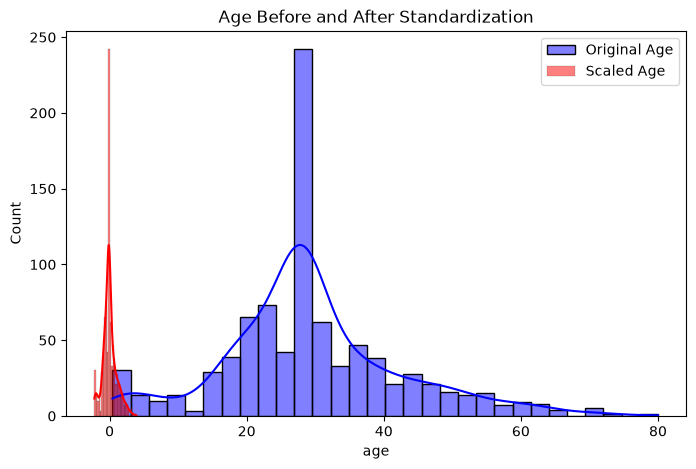

In [61]:
#Distribution Comparison
plt.figure(figsize=(8,5))

sns.histplot(clean_df["age"], color="blue", label="Original Age", kde=True)

sns.histplot(clean_df["age_scaled"], color="red", label="Scaled Age", kde=True)

plt.legend()

plt.title("Age Before and After Standardization")

plt.show()

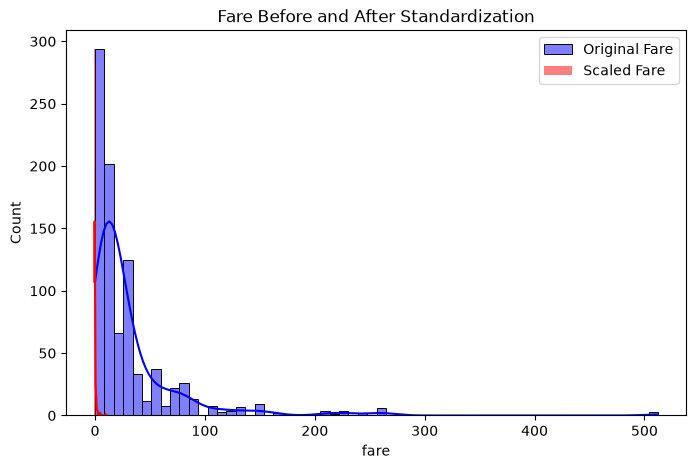

In [62]:
#Fare Before and After Standardization
plt.figure(figsize=(8,5))

sns.histplot(clean_df["fare"], color="blue", label="Original Fare", kde=True)

sns.histplot(clean_df["fare_scaled"], color="red", label="Scaled Fare", kde=True)

plt.legend()

plt.title("Fare Before and After Standardization")

plt.show()

## Interpretation

The standardized Age and Fare variables have means close to zero and standard deviations close to one, confirming that the Z-score transformation was successful. This standardization was performed only for exploratory analysis and will not be used directly in the machine learning pipeline, where scaling will be applied only to the training data.